# D_S3 — Full paired SNR sweep generation

Regenerates the 14 selected signal families for the `mild`, `standard`, and `strong` variants over one common 227-level SNR grid. Within each family × variant × replicate trajectory, `x`, branch assignment, and the standard-normal noise vector are fixed; only the noise scale changes. This makes the degradation path across SNR directly comparable.

Full design: 14 families × 3 variants × 227 SNR levels × 10 replicates = **95,340 signal cases**, plus **100 independent Null controls**. Each case contains 500 points.

The notebook defaults to `full`. For a small validation run, launch it with `SNR_SWEEP_MODE=pilot`.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kwargs):
        return it

try:
    from IPython.display import display
except ImportError:
    display = print

os.environ.setdefault('MPLCONFIGDIR', str((Path.cwd() / '.matplotlib').resolve()))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration and source reuse

Function formulas and the three parameter variants are loaded from `D_S1_scatterplot_generation.ipynb`. The source notebook is not executed as an experiment and is not modified.

In [2]:
RUN_MODE = os.environ.get('SNR_SWEEP_MODE', 'full').strip().lower()
if RUN_MODE not in {'full', 'pilot'}:
    raise ValueError("SNR_SWEEP_MODE must be 'full' or 'pilot'")

OVERWRITE = os.environ.get('SNR_SWEEP_OVERWRITE', '0') == '1'
MASTER_SEED = 20260720

SELECTED_FAMILIES = [
    'F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18',
    'F21', 'F19', 'F23', 'F24', 'F25', 'F26', 'F22',
]
VARIANT_LEVELS = ['mild', 'standard', 'strong']

def locate_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for root in candidates:
        if (root / 'D' / 'D_S1_scatterplot_generation.ipynb').exists():
            return root
    raise FileNotFoundError('Could not locate D/D_S1_scatterplot_generation.ipynb')

REPO_ROOT = locate_repo_root()
GLOBAL_DIR = REPO_ROOT / 'D' / 'Global'
SOURCE_S1 = REPO_ROOT / 'D' / 'D_S1_scatterplot_generation.ipynb'
BASE_OUTPUT_DIR = GLOBAL_DIR / 'output' / 'S3_snr_mic_sweep'
OUTPUT_DIR = BASE_OUTPUT_DIR if RUN_MODE == 'full' else BASE_OUTPUT_DIR / '_pilot'

with SOURCE_S1.open('r', encoding='utf-8') as handle:
    source_nb = json.load(handle)

def source_cell(index: int) -> str:
    return ''.join(source_nb['cells'][index]['source'])

# S1 cell 3: constants + labels; cell 5: ShapeConfig and parameter variants.
exec(compile(source_cell(3), f'{SOURCE_S1.name}:cell3', 'exec'), globals())
# The source cell defines its own legacy output path; restore this experiment's isolated path.
OUTPUT_DIR = BASE_OUTPUT_DIR if RUN_MODE == 'full' else BASE_OUTPUT_DIR / '_pilot'
shape_cell = source_cell(5).split('\nshape_configs = build_shape_configs()', 1)[0]
exec(compile(shape_cell, f'{SOURCE_S1.name}:cell5', 'exec'), globals())
shape_configs_all = build_shape_configs()

# S1 cells 7 and 9: signal evaluation, x sampling, variance, and SNR scaling.
exec(compile(source_cell(7), f'{SOURCE_S1.name}:cell7', 'exec'), globals())
exec(compile(source_cell(9), f'{SOURCE_S1.name}:cell9', 'exec'), globals())

shape_configs = [
    cfg for cfg in shape_configs_all
    if cfg.family_id in SELECTED_FAMILIES and cfg.variant_level in VARIANT_LEVELS
]
shape_configs.sort(key=lambda cfg: (
    SELECTED_FAMILIES.index(cfg.family_id), VARIANT_LEVELS.index(cfg.variant_level)
))

assert len(shape_configs) == 14 * 3
assert all(sum(cfg.family_id == fid for cfg in shape_configs) == 3 for fid in SELECTED_FAMILIES)
print(f'RUN_MODE: {RUN_MODE}')
print(f'Source S1: {SOURCE_S1}')
print(f'Output: {OUTPUT_DIR}')
print(f'Selected shape configurations: {len(shape_configs)}')

,family_id,family_name,equation_presentation,basic_label,direction,linearity,monotonicity,curvature,special_shape,tp_number
0,F01,Linear positive,"y = ax + b, a > 0",slope a,positive,linear,monotonic,N/A,none,0
1,F02,Linear negative,"y = ax + b, a < 0",slope a,negative,linear,monotonic,N/A,none,0
2,F03,Power convex positive,"y = x^p, p > 1",exponent p,positive,nonlinear,monotonic,convex,none,0
3,F04,Power convex negative,"y = -x^p, p > 1",exponent p,negative,nonlinear,monotonic,concave,none,0
4,F05,Power concave positive,"y = x^p, 0 < p < 1",exponent p,positive,nonlinear,monotonic,concave,none,0
5,F06,Power concave negative,"y = -x^p, 0 < p < 1",exponent p,negative,nonlinear,monotonic,convex,none,0
6,F07,Saturation positive,y = 1 - exp(-kx),rate k,positive,nonlinear,monotonic,concave,saturation,0
7,F08,Saturation negative,y = -(1 - exp(-kx)),rate k,negative,nonlinear,monotonic,convex,saturation,0
8,F09,Log positive,y = log(1 + ax),scale a,positive,nonlinear,monotonic,concave,none,0
9,F10,Log negative,y = -log(1 + ax),scale a,negative,nonlinear,monotonic,convex,none,0


RUN_MODE: pilot
Source S1: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/D_S1_scatterplot_generation.ipynb
Output: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/D/Global/output/S3_snr_mic_sweep/_pilot
Selected shape configurations: 42


## Build the 227-level SNR grid

- Original S1 grid: 200 geometric values from 0.001 to 500, five high-SNR values, and infinity = 206 levels.
- Add SNR = 100.
- Add 20 values evenly spaced on the `1/SNR` axis strictly between infinity and 100.
- Merge and deduplicate = 227 levels.

In [3]:
original_snr = sorted(
    np.geomspace(0.001, 500, 200).tolist() + [750.0, 1000.0, 2000.0, 5000.0, 10000.0]
) + [math.inf]

high_inverse_snr = np.linspace(0.0, 0.01, 22)[1:-1]
added_high_snr = (1.0 / high_inverse_snr).tolist()
finite_snr = sorted(set(float(v) for v in original_snr if np.isfinite(v)) | {100.0} | set(added_high_snr))
full_snr_grid = finite_snr + [math.inf]

assert len(original_snr) == 206
assert len(added_high_snr) == 20
assert len(full_snr_grid) == 227
assert full_snr_grid[-1] == math.inf

if RUN_MODE == 'pilot':
    active_families = ['F01', 'F23']
    active_configs = [cfg for cfg in shape_configs if cfg.family_id in active_families]
    SNR_GRID = [0.1, 1.0, 10.0, 100.0, math.inf]
    N_SIGNAL_REPLICATES = 2
    N_PER_CASE = 100
    N_NULL = 10
else:
    active_families = SELECTED_FAMILIES
    active_configs = shape_configs
    SNR_GRID = full_snr_grid
    N_SIGNAL_REPLICATES = 10
    N_PER_CASE = 500
    N_NULL = 100

N_SIGNAL = len(active_configs) * len(SNR_GRID) * N_SIGNAL_REPLICATES
N_TOTAL = N_SIGNAL + N_NULL

grid_preview = pd.DataFrame({
    'snr': full_snr_grid,
    'inverse_snr': [0.0 if math.isinf(v) else 1.0 / v for v in full_snr_grid],
    'is_added_high_snr': [
        any(np.isclose(v, a, rtol=1e-12, atol=0.0) for a in added_high_snr) if np.isfinite(v) else False
        for v in full_snr_grid
    ],
})

print(f'Full SNR levels: {len(full_snr_grid)}')
print(f'Active SNR levels: {len(SNR_GRID)}')
print(f'Cases: {N_SIGNAL:,} signal + {N_NULL:,} Null = {N_TOTAL:,}')
print(f'Points per case: {N_PER_CASE}')
display(grid_preview.tail(30))

Full SNR levels: 227
Active SNR levels: 5
Cases: 60 signal + 10 Null = 70
Points per case: 100


,snr,inverse_snr,is_added_high_snr
197,2.100000e+02,0.004762,True
198,2.121658e+02,0.004713,False
199,2.266280e+02,0.004413,False
200,2.333333e+02,0.004286,True
201,2.420759e+02,0.004131,False
202,2.585768e+02,0.003867,False
203,2.625000e+02,0.003810,True
204,2.762025e+02,0.003621,False
205,2.950297e+02,0.003389,False
206,3.000000e+02,0.003333,True


## Generate paired SNR trajectories

The deterministic seed is split by family, variant, replicate, and component. Every SNR case in one trajectory therefore shares the same `x`, noiseless signal/branch realization, and standard-normal noise draw.

In [4]:
def stable_seed(*parts: Any) -> int:
    payload = '|'.join(map(str, (MASTER_SEED, *parts))).encode('utf-8')
    return int.from_bytes(hashlib.blake2b(payload, digest_size=8).digest(), 'little')

def snr_zone(snr: float) -> str:
    if math.isinf(float(snr)) or snr >= 5.0:
        return 'clear'
    if snr >= 1.0:
        return 'clear_to_fuzzy'
    if snr >= 0.4:
        return 'fuzzy_to_unrecognisable'
    return 'unrecognisable'

x_all = np.empty((N_TOTAL, N_PER_CASE), dtype=np.float32)
y_all = np.empty((N_TOTAL, N_PER_CASE), dtype=np.float32)
records: list[dict[str, Any]] = []

row = 0
started = time.time()
for cfg in tqdm(active_configs, desc='shape configurations'):
    labels = FAMILY_LABELS[cfg.family_id]
    theoretical_signal_variance = signal_variance_under_uniform(cfg)

    for repeat in range(1, N_SIGNAL_REPLICATES + 1):
        trajectory_id = f'{cfg.family_id}_{cfg.variant_level}_r{repeat:02d}'
        x = sample_x(N_PER_CASE, X_DISTRIBUTION, np.random.default_rng(stable_seed(trajectory_id, 'x')))
        y_signal = evaluate_signal(x, cfg, rng=np.random.default_rng(stable_seed(trajectory_id, 'branch')))
        noise_z = np.random.default_rng(stable_seed(trajectory_id, 'noise')).normal(0.0, 1.0, N_PER_CASE)
        spread = spread_multiplier(x, SPREAD_PATTERN)
        sample_signal_variance = float(np.var(y_signal, ddof=0))

        for snr in SNR_GRID:
            sigma0 = sigma0_for_snr(cfg, snr)
            noise = sigma0 * spread * noise_z
            y = y_signal + noise
            sample_noise_variance = float(np.var(noise, ddof=0))
            actual_snr = (
                math.inf if sample_noise_variance == 0.0
                else sample_signal_variance / sample_noise_variance
            )
            case_id = f'S{row + 1:06d}'

            x_all[row] = x
            y_all[row] = y
            records.append({
                'candidate_index': row,
                'case_id': case_id,
                'trajectory_id': trajectory_id,
                'family_id': cfg.family_id,
                'family_name': labels['family_name'],
                'shape_config_id': cfg.shape_config_id,
                'variant_name': cfg.variant_name,
                'variant_level': cfg.variant_level,
                'repeat': repeat,
                'nominal_snr': float(snr),
                'inverse_snr': 0.0 if math.isinf(float(snr)) else 1.0 / float(snr),
                'actual_snr': float(actual_snr),
                'sigma0': float(sigma0),
                'snr_zone': snr_zone(float(snr)),
                'n_points': N_PER_CASE,
                'x_distribution': X_DISTRIBUTION,
                'spread_pattern': SPREAD_PATTERN,
                'trajectory_seed': stable_seed(trajectory_id),
                'is_null': False,
                'params_json': json.dumps(cfg.params, sort_keys=True),
            })
            row += 1

# Null has no SNR. These 100 controls are independent of one another.
for null_repeat in range(1, N_NULL + 1):
    null_id = f'Null_r{null_repeat:03d}'
    rng_x = np.random.default_rng(stable_seed(null_id, 'x'))
    rng_y = np.random.default_rng(stable_seed(null_id, 'y'))
    x = rng_x.uniform(0.0, 1.0, N_PER_CASE)
    y = rng_y.normal(0.0, 1.0, N_PER_CASE)
    case_id = f'N{null_repeat:03d}'

    x_all[row] = x
    y_all[row] = y
    records.append({
        'candidate_index': row,
        'case_id': case_id,
        'trajectory_id': null_id,
        'family_id': 'Null',
        'family_name': 'No relationship',
        'shape_config_id': -1,
        'variant_name': 'independent_normal',
        'variant_level': 'none',
        'repeat': null_repeat,
        'nominal_snr': np.nan,
        'inverse_snr': np.nan,
        'actual_snr': np.nan,
        'sigma0': np.nan,
        'snr_zone': 'null',
        'n_points': N_PER_CASE,
        'x_distribution': 'even',
        'spread_pattern': 'constant',
        'trajectory_seed': stable_seed(null_id),
        'is_null': True,
        'params_json': '{}',
    })
    row += 1

cases_df = pd.DataFrame(records)
assert row == N_TOTAL == len(cases_df) == len(x_all) == len(y_all)
assert cases_df['candidate_index'].tolist() == list(range(N_TOTAL))
assert cases_df.loc[~cases_df['is_null'], 'case_id'].is_unique
assert cases_df.loc[cases_df['is_null'], 'nominal_snr'].isna().all()

elapsed = time.time() - started
print(f'Generated {N_TOTAL:,} cases in {elapsed / 60:.1f} minutes')
display(cases_df.head())
display(cases_df.tail())

shape configurations:   0%|          | 0/6 [00:00<?, ?it/s]

shape configurations: 100%|██████████| 6/6 [00:00<00:00, 665.83it/s]

Generated 70 cases in 0.0 minutes


,candidate_index,case_id,trajectory_id,family_id,family_name,shape_config_id,variant_name,variant_level,repeat,nominal_snr,inverse_snr,actual_snr,sigma0,snr_zone,n_points,x_distribution,spread_pattern,trajectory_seed,is_null,params_json
0,0,S000001,F01_mild_r01,F01,Linear positive,1,slope_0.3,mild,1,0.1,10.00,0.119862,0.273875,unrecognisable,100,even,constant,8654580185156642026,False,"{""intercept"": 0.0, ""slope"": 0.3}"
1,1,S000002,F01_mild_r01,F01,Linear positive,1,slope_0.3,mild,1,1.0,1.00,1.198622,0.086607,clear_to_fuzzy,100,even,constant,8654580185156642026,False,"{""intercept"": 0.0, ""slope"": 0.3}"
2,2,S000003,F01_mild_r01,F01,Linear positive,1,slope_0.3,mild,1,10.0,0.10,11.986223,0.027387,clear,100,even,constant,8654580185156642026,False,"{""intercept"": 0.0, ""slope"": 0.3}"
3,3,S000004,F01_mild_r01,F01,Linear positive,1,slope_0.3,mild,1,100.0,0.01,119.862232,0.008661,clear,100,even,constant,8654580185156642026,False,"{""intercept"": 0.0, ""slope"": 0.3}"
4,4,S000005,F01_mild_r01,F01,Linear positive,1,slope_0.3,mild,1,inf,0.00,inf,0.000000,clear,100,even,constant,8654580185156642026,False,"{""intercept"": 0.0, ""slope"": 0.3}"


,candidate_index,case_id,trajectory_id,family_id,family_name,shape_config_id,variant_name,variant_level,repeat,nominal_snr,inverse_snr,actual_snr,sigma0,snr_zone,n_points,x_distribution,spread_pattern,trajectory_seed,is_null,params_json
65,65,N006,Null_r006,Null,No relationship,-1,independent_normal,none,6,NaN,NaN,NaN,NaN,null,100,even,constant,5709467209644022662,True,{}
66,66,N007,Null_r007,Null,No relationship,-1,independent_normal,none,7,NaN,NaN,NaN,NaN,null,100,even,constant,3628013788976216204,True,{}
67,67,N008,Null_r008,Null,No relationship,-1,independent_normal,none,8,NaN,NaN,NaN,NaN,null,100,even,constant,5814094604027838479,True,{}
68,68,N009,Null_r009,Null,No relationship,-1,independent_normal,none,9,NaN,NaN,NaN,NaN,null,100,even,constant,3124230221545054187,True,{}
69,69,N010,Null_r010,Null,No relationship,-1,independent_normal,none,10,NaN,NaN,NaN,NaN,null,100,even,constant,17527852536299723067,True,{}


## Save one self-contained dataset folder

In [5]:
OUTPUT_DIR.parent.mkdir(parents=True, exist_ok=True)
expected_outputs = [
    OUTPUT_DIR / 'cases.csv',
    OUTPUT_DIR / 'scatter_points.npz',
    OUTPUT_DIR / 'generation_metadata.json',
]
existing = [path for path in expected_outputs if path.exists()]
if existing and not OVERWRITE:
    raise FileExistsError(
        'Output already exists. Set SNR_SWEEP_OVERWRITE=1 only if replacement is intended: '
        + ', '.join(map(str, existing))
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
cases_df.to_csv(OUTPUT_DIR / 'cases.csv', index=False)
np.savez(OUTPUT_DIR / 'scatter_points.npz', x=x_all, y=y_all)

metadata = {
    'run_mode': RUN_MODE,
    'master_seed': MASTER_SEED,
    'source_s1': str(SOURCE_S1),
    'selected_families': active_families,
    'variant_levels': VARIANT_LEVELS,
    'n_shape_configs': len(active_configs),
    'n_signal_replicates': N_SIGNAL_REPLICATES,
    'n_null': N_NULL,
    'n_points_per_case': N_PER_CASE,
    'n_snr_levels': len(SNR_GRID),
    'snr_grid': ['inf' if math.isinf(v) else float(v) for v in SNR_GRID],
    'n_signal_cases': N_SIGNAL,
    'n_total_cases': N_TOTAL,
    'paired_trajectory': True,
    'pairing_definition': 'same x, branch assignment, and standard-normal noise vector; scale changes by SNR',
    'x_distribution': X_DISTRIBUTION,
    'spread_pattern': SPREAD_PATTERN,
    'elapsed_seconds': elapsed,
}
with (OUTPUT_DIR / 'generation_metadata.json').open('w', encoding='utf-8') as handle:
    json.dump(metadata, handle, indent=2, ensure_ascii=False)

print('Saved:')
for path in expected_outputs:
    print(f'  {path.name}: {path.stat().st_size / 1024**2:.2f} MiB')

Saved:
  cases.csv: 0.01 MiB
  scatter_points.npz: 0.05 MiB
  generation_metadata.json: 0.00 MiB


## Validation and trajectory preview

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_19988/197682155.py:19: RuntimeWarning: divide by zero encountered in log10
  lambda value: min(abs(np.log10(value / target)) if np.isfinite(value) else (0.0 if np.isinf(target) else np.inf)


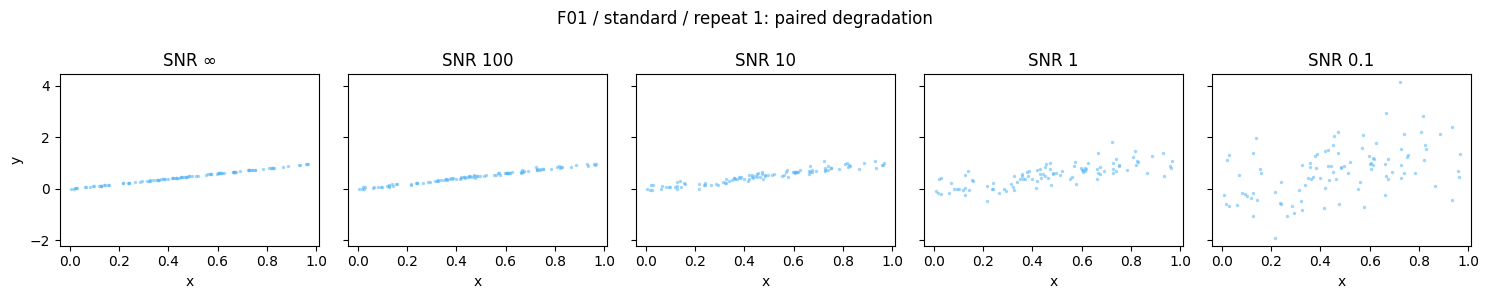

Validation passed.


In [6]:
loaded_cases = pd.read_csv(OUTPUT_DIR / 'cases.csv', low_memory=False)
with np.load(OUTPUT_DIR / 'scatter_points.npz') as points:
    loaded_x = points['x']
    loaded_y = points['y']

assert len(loaded_cases) == loaded_x.shape[0] == loaded_y.shape[0] == N_TOTAL
assert loaded_x.shape[1] == loaded_y.shape[1] == N_PER_CASE
assert loaded_cases['candidate_index'].to_numpy().tolist() == list(range(N_TOTAL))

preview_family = active_families[0]
preview_variant = 'standard'
preview_repeat = 1
preview = loaded_cases[
    (loaded_cases['family_id'] == preview_family)
    & (loaded_cases['variant_level'] == preview_variant)
    & (loaded_cases['repeat'] == preview_repeat)
].copy()
preview_rows = []
for target in [math.inf, 100.0, 10.0, 1.0, 0.1]:
    if math.isinf(target):
        chosen = preview[np.isinf(preview['nominal_snr'])].iloc[0]
    else:
        finite = preview[np.isfinite(preview['nominal_snr'])].copy()
        chosen = finite.iloc[np.abs(np.log(finite['nominal_snr'] / target)).argmin()]
    preview_rows.append(chosen)

fig, axes = plt.subplots(1, len(preview_rows), figsize=(15, 3), sharex=True, sharey=True)
for ax, case in zip(axes, preview_rows):
    idx = int(case['candidate_index'])
    ax.scatter(loaded_x[idx], loaded_y[idx], s=6, alpha=0.55, color='#55B5F8', linewidths=0)
    title_snr = '∞' if np.isinf(case['nominal_snr']) else f"{case['nominal_snr']:.3g}"
    ax.set_title(f'SNR {title_snr}')
    ax.set_xlabel('x')
axes[0].set_ylabel('y')
fig.suptitle(f'{preview_family} / {preview_variant} / repeat {preview_repeat}: paired degradation')
fig.tight_layout()
plt.show()

print('Validation passed.')